# Tutorial: `pyweatherfiles` end-to-end (Seville case study)

This notebook is a hands-on tutorial for the **`pyweatherfiles`** package. It
reproduces, step by step, the same pipeline used for the real Seville case
study (`generating epws seville.py`, [`ARTICLE_CONTEXT_SEVILLA.md`](../ARTICLE_CONTEXT_SEVILLA.md)):

1. **Input data** — a reproducible synthetic hourly weather series (so this
   notebook runs identically for anyone who clones the repository, with no
   external downloads required).
2. **`TMYGenerator`** — generate a Typical Meteorological Year (Sandia method,
   7 steps, sequential persistence filtering).
3. **`HourlyEPWConverter`** — export the TMY to a final `.epw` file.
4. **`DegreeHoursCalculator`** — heating/cooling degree-hours against a real
   EnergyPlus IDF model bundled in this repository.
5. **`EpwBatchAnalyzer`** — compare the generated TMY against a real
   historical year from `longterm_epw/`.
6. **`EpwTrendAnalyzer`** *(bonus)* — multi-year warming trend over the full
   `longterm_epw/` collection (2005-2025, with a missing year on purpose).

For the complete technical reference of every module/class/formula, see the
full documentation: {doc}`Sphinx site <../docs/source/index>`, or directly
[`README.md`](../README.md) / [`README_ES.md`](../README_ES.md).

```{note}
Most calls below use `save_session=False` to avoid littering the repository
with `.pkl`/`.json` session files every time this notebook runs. In real
projects the default `save_session=True` is recommended for full
reproducibility (see README, section 10, "session_manager"). The one place
where a session file cannot be avoided (`EpwBatchAnalyzer`, which internally
calls `DegreeHoursCalculator.calculate()` without exposing `save_session`) is
cleaned up explicitly at the end of section 5.
```


## 0. Setup

Locate the repository root (so relative paths work no matter where Jupyter was launched from) and create a scratch output folder for this tutorial.

In [1]:
import os
import sys

def find_repo_root(start=None):
    path = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.exists(os.path.join(path, "pyproject.toml")):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError("Could not locate repository root (pyproject.toml not found).")
        path = parent

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
sys.path.insert(0, REPO_ROOT)
print("Repository root:", REPO_ROOT)

OUT_DIR = os.path.join(REPO_ROOT, "examples", "tutorial_output")
os.makedirs(OUT_DIR, exist_ok=True)
print("Tutorial output folder:", OUT_DIR)


Repository root: D:\Python\pyweatherfiles
Tutorial output folder: D:\Python\pyweatherfiles\examples\tutorial_output


## 1. Input data: a reproducible synthetic hourly series

The real Seville workflow (`generating epws seville.py`) reads
`Sevilla_Definitivo_para_convertir_a_epw.xlsx`, a large raw data file that is
**not** tracked in git (see `.gitignore`: `*.xlsx`). To make this tutorial
100% reproducible for anyone who clones the repository, we generate a
synthetic-but-realistic **6-year hourly series** (2015-2020) with a fixed
random seed, using the *exact same column names* as the real Seville file
(`Dry-bulb temperature`, `Dew Point temperature`, `Wind Speed`,
`Global Horizontal Irradiance `, `Beam Normal Irradiance `). This means the
`column_mapping` used here is directly transferable to the real dataset.

```{tip}
`TMYGenerator` requires a **minimum of 5 years** of data (see
`sandia_step_1_load_and_prepare`); that's why 6 years are generated here.
```


In [2]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)  # fixed seed -> fully reproducible
years = list(range(2015, 2021))  # 6 years
idx = pd.date_range(f"{years[0]}-01-01", f"{years[-1]}-12-31 23:00", freq="h")
n = len(idx)
doy = idx.dayofyear.values.astype(float)
hour = idx.hour.values.astype(float)
year_arr = idx.year.values

# Seasonal (annual) + diurnal temperature cycle, Seville-like (Csa Mediterranean climate)
seasonal = 8.0 * np.sin(2 * np.pi * (doy - 105) / 365.25)
diurnal = 6.0 * np.sin(2 * np.pi * (hour - 9) / 24.0)
noise = rng.normal(0, 1.5, n)
interannual_by_year = rng.normal(0, 0.6, len(years))  # small year-to-year variability
interannual = interannual_by_year[year_arr - years[0]]
t_air = 18.0 + seasonal + diurnal + noise + interannual

dew_depression = np.clip(rng.normal(6.0, 2.5, n), 0.5, None)
t_dew = t_air - dew_depression

wind = np.clip(10 + 4 * np.sin(2 * np.pi * doy / 365.25 + 1) + rng.normal(0, 3, n), 0.2, None)

# Very simplified solar geometry to build a realistic GHI/DNI daily+seasonal cycle
day_length_factor = 0.5 + 0.5 * np.sin(2 * np.pi * (doy - 80) / 365.25)
hour_angle = (hour - 12) / 12 * np.pi
cos_elev = np.clip(np.cos(hour_angle) * (0.4 + 0.6 * day_length_factor), 0, None)
clear_sky_ghi = 1000 * cos_elev ** 1.2
cloudiness = np.clip(rng.beta(2, 5, n), 0, 1)  # mostly clear, occasional cloudy spells
ghi = np.clip(clear_sky_ghi * (1 - 0.8 * cloudiness), 0, None)
dni = np.clip(ghi * (0.7 - 0.5 * cloudiness), 0, None)

df_synthetic = pd.DataFrame({
    "time": idx,
    "Dry-bulb temperature": np.round(t_air, 2),
    "Dew Point temperature": np.round(t_dew, 2),
    "Wind Speed": np.round(wind, 2),
    "Global Horizontal Irradiance ": np.round(ghi, 1),   # trailing space matches the real Seville file
    "Beam Normal Irradiance ": np.round(dni, 1),          # trailing space matches the real Seville file
})

synthetic_path = os.path.join(OUT_DIR, "synthetic_hourly_data.csv")
df_synthetic.to_csv(synthetic_path, index=False)
print("Wrote", synthetic_path)
df_synthetic.describe()


Wrote D:\Python\pyweatherfiles\examples\tutorial_output\synthetic_hourly_data.csv


,time,Dry-bulb temperature,Dew Point temperature,Wind Speed,Global Horizontal Irradiance,Beam Normal Irradiance
count,52608,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000
mean,2017-12-31 23:30:00,18.250364,12.262624,10.008318,152.119872,86.706001
min,2015-01-01 00:00:00,-1.410000,-10.570000,0.200000,0.000000,0.000000
25%,2016-07-01 23:45:00,12.950000,6.710000,7.080000,0.000000,0.000000
50%,2017-12-31 23:30:00,18.230000,12.290000,9.990000,0.000000,0.000000
75%,2019-07-02 23:15:00,23.530000,17.812500,12.970000,268.025000,145.500000
max,2020-12-31 23:00:00,36.920000,36.110000,25.650000,980.100000,674.100000
std,NaN,7.274759,7.672804,4.108416,215.470697,127.732890


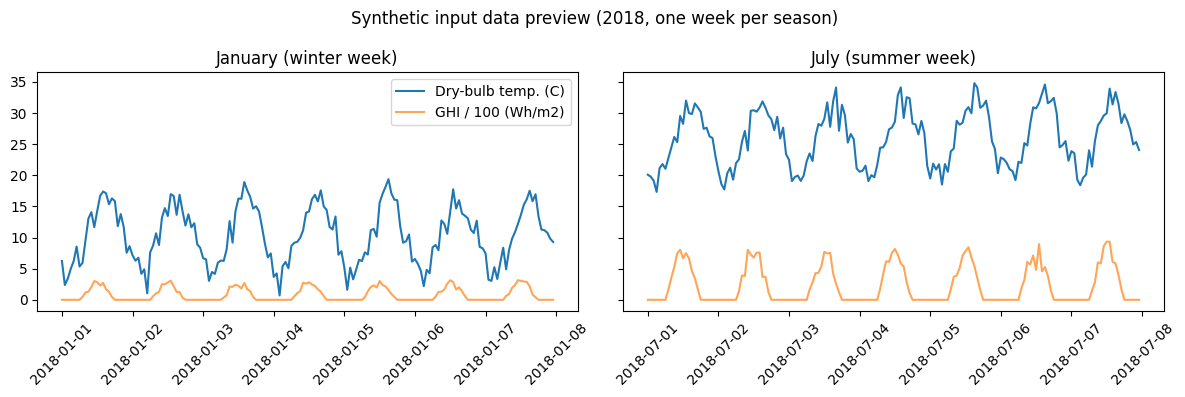

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, month, label in zip(axes, [1, 7], ["January (winter week)", "July (summer week)"]):
    week = df_synthetic[(df_synthetic["time"].dt.year == 2018) & (df_synthetic["time"].dt.month == month)].iloc[:24 * 7]
    ax.plot(week["time"], week["Dry-bulb temperature"], label="Dry-bulb temp. (C)")
    ax.plot(week["time"], week["Global Horizontal Irradiance "] / 100, label="GHI / 100 (Wh/m2)", alpha=0.7)
    ax.set_title(label)
    ax.tick_params(axis="x", rotation=45)
axes[0].legend()
fig.suptitle("Synthetic input data preview (2018, one week per season)")
fig.tight_layout()
plt.show()


## 2. Generate a Typical Meteorological Year with `TMYGenerator`

We follow the same pattern used in `generating epws seville.py`:
`cdf_method='daily'` (fast Finkelstein-Schafer candidate selection using daily
aggregates) combined with `hourly_file_path` pointing at the **same** file, so
Step 6 (assembly) and Step 7 (junction smoothing) still use full hourly
resolution. This is the recommended pattern for long datasets (see README,
section 13, "Design notes").


In [4]:
from pyweatherfiles import tmy

gen = tmy.TMYGenerator(
    file_path=synthetic_path,
    cdf_method="daily",
    data_frequency="hourly",
    hourly_file_path=synthetic_path,
    weighting_method="sandia",
    save_validation_dfs=True,
    datetime_col="time",
    col_temp="Dry-bulb temperature",
    col_dew="Dew Point temperature",
    col_wind="Wind Speed",
    col_ghi="Global Horizontal Irradiance ",
    col_dni="Beam Normal Irradiance ",
    save_session=False,
)
gen.generate_tmy(use_persistence=True)


Using 'hazen' plotting position for CDF calculation.
--- Starting full TMY generation workflow ---
Loading and preparing data from 'D:\Python\pyweatherfiles\examples\tutorial_output\synthetic_hourly_data.csv'...
Using all available years in the file: [2015, 2016, 2017, 2018, 2019, 2020]
Resampling data to hourly frequency and interpolating gaps...
Calculating daily aggregations for weighting method: sandia...
DEBUG: df_daily columns created: ['T_air_mean', 'T_air_max', 'T_air_min', 'T_dew_mean', 'T_dew_max', 'T_dew_min', 'Wind_speed_mean', 'Wind_speed_max', 'GHI_sum']

Loading hourly data from 'D:\Python\pyweatherfiles\examples\tutorial_output\synthetic_hourly_data.csv'...


Resampling hourly data and interpolating gaps...
Filtering hourly data to only include months available in daily data...
Hourly data loaded successfully with 52608 records.
Real data loaded and prepared.
Step 2: Calculating FS statistics using 'daily' method...
  Month 1: Selected candidates -> [2018, 2015, 2016, 2019, 2017]
  Month 2: Selected candidates -> [2016, 2018, 2015, 2017, 2019]
  Month 3: Selected candidates -> [2018, 2016, 2015, 2019, 2017]
  Month 4: Selected candidates -> [2016, 2019, 2015, 2018, 2017]


D:\Python\pyweatherfiles\pyweatherfiles\tmy.py:595: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  available_months_in_daily = set(self.df_daily.index.to_period('M'))
D:\Python\pyweatherfiles\pyweatherfiles\tmy.py:599: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  hourly_periods = df_hourly_source.index.to_period('M')


  Month 5: Selected candidates -> [2015, 2016, 2018, 2019, 2017]
  Month 6: Selected candidates -> [2016, 2018, 2015, 2019, 2017]
  Month 7: Selected candidates -> [2015, 2018, 2019, 2016, 2017]
  Month 8: Selected candidates -> [2018, 2016, 2015, 2017, 2019]
  Month 9: Selected candidates -> [2018, 2016, 2019, 2015, 2017]
  Month 10: Selected candidates -> [2018, 2016, 2019, 2015, 2017]
  Month 11: Selected candidates -> [2018, 2016, 2015, 2019, 2017]


  Month 12: Selected candidates -> [2016, 2015, 2018, 2019, 2017]
Step 3: Applying Proximity Ranking to re-order top 5 candidates (method='std')...
  Month 1: Re-ordered by Proximity -> [2018, 2015, 2019, 2016, 2017]
  Month 2: Re-ordered by Proximity -> [2018, 2016, 2015, 2019, 2017]
  Month 3: Re-ordered by Proximity -> [2016, 2018, 2015, 2019, 2017]
  Month 4: Re-ordered by Proximity -> [2018, 2016, 2019, 2015, 2017]
  Month 5: Re-ordered by Proximity -> [2018, 2016, 2015, 2019, 2017]
  Month 6: Re-ordered by Proximity -> [2016, 2018, 2015, 2019, 2017]
  Month 7: Re-ordered by Proximity -> [2018, 2016, 2015, 2019, 2017]
  Month 8: Re-ordered by Proximity -> [2018, 2016, 2015, 2019, 2017]
  Month 9: Re-ordered by Proximity -> [2018, 2016, 2015, 2019, 2017]
  Month 10: Re-ordered by Proximity -> [2018, 2016, 2019, 2015, 2017]
  Month 11: Re-ordered by Proximity -> [2018, 2016, 2015, 2019, 2017]
  Month 12: Re-ordered by Proximity -> [2018, 2016, 2015, 2019, 2017]



Applying persistence criteria (Step 4) and Final Selection (Step 5)...



Step 6: Creating raw (un-smoothed) TMY...
  Leap year adjustment: Removing Feb 29th from year 2016.
Applying sophisticated smoothing at month junctions...
  - Junction 1->2: hours_before=6, hours_after=6, s_factor=0.0
  - Junction 2->3: hours_before=6, hours_after=6, s_factor=0.0
  - Junction 3->4: hours_before=6, hours_after=6, s_factor=0.0
  - Junction 4->5: hours_before=6, hours_after=6, s_factor=0.0
  - Junction 5->6: hours_before=6, hours_after=6, s_factor=0.0
  - Junction 6->7: hours_before=6, hours_after=6, s_factor=0.0
  - Junction 7->8: hours_before=6, hours_after=6, s_factor=0.0
  - Junction 8->9: hours_before=6, hours_after=6, s_factor=0.0
  - Junction 9->10: hours_before=6, hours_after=6, s_factor=0.0
  - Junction 10->11: hours_before=6, hours_after=6, s_factor=0.0
  - Junction 11->12: hours_before=6, hours_after=6, s_factor=0.0
Final TMY generated and smoothed.


Full summary generated: 12 months. Stored in 'self.validation_full_summary'.

--- Full TMY generation finished ---


`generate_full_summary()` (called automatically at the end of Step 7) produces a one-row-per-month consolidated table with the source year selected for each month and how it compares to the long-term climate:

In [5]:
gen.validation_full_summary

,Month,Month_Num,Source_Year,FS_Total_W_FS,FS_Rank_Overall,FS_Num_Years,Prox_Rank,Persist_NumRuns,Persist_MaxRun,Persist_Decision,LT_T_mean,Sel_T_mean,T_diff,LT_GHI_mean,Sel_GHI_mean,GHI_diff
0,January,1,2018,0.059725,1,6,1,11,6,SELECTED TMY MONTH,10.36,10.24,-0.12,2040.84,2058.45,17.61
1,February,2,2016,0.055485,1,6,2,8,11,SELECTED TMY MONTH,11.52,11.12,-0.39,2611.58,2638.98,27.39
2,March,3,2016,0.049616,2,6,1,8,11,SELECTED TMY MONTH,14.35,14.08,-0.27,3475.79,3442.97,-32.82
3,April,4,2016,0.044421,1,6,2,7,11,SELECTED TMY MONTH,18.38,18.07,-0.31,4373.85,4399.15,25.29
4,May,5,2018,0.063136,3,6,1,9,11,SELECTED TMY MONTH,22.28,21.99,-0.29,5195.33,5152.59,-42.74
5,June,6,2018,0.058148,2,6,2,9,11,SELECTED TMY MONTH,25.16,25.05,-0.10,5506.24,5552.53,46.29
6,July,7,2018,0.073014,2,6,1,13,4,SELECTED TMY MONTH,26.12,25.93,-0.19,5331.18,5374.05,42.87
7,August,8,2016,0.065730,2,6,2,8,12,SELECTED TMY MONTH,25.02,24.60,-0.41,4651.35,4659.61,8.26
8,September,9,2018,0.040324,1,6,1,8,9,SELECTED TMY MONTH,22.03,21.88,-0.15,3758.43,3773.85,15.42
9,October,10,2018,0.042512,1,6,1,6,12,SELECTED TMY MONTH,18.01,17.83,-0.19,2816.91,2826.90,9.99


A couple of the built-in diagnostic plots (see README section 3.10 for the full list):


--- Plotting Monthly Mean Comparison: Final TMY vs. Long-term ---


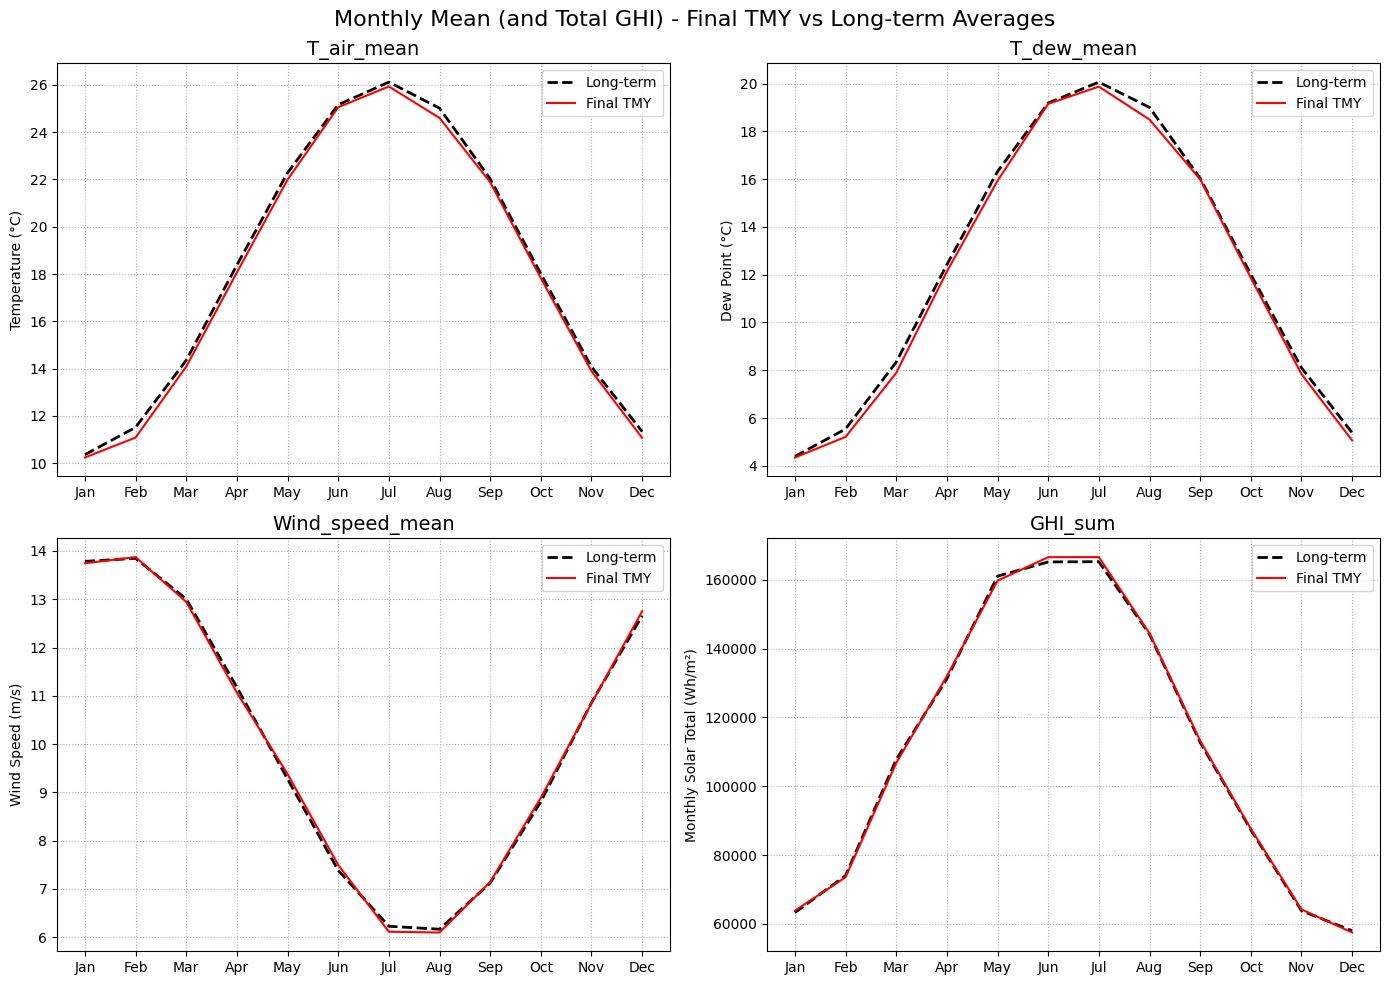

In [6]:
gen.plot_monthly_means()
plt.show()



--- Plotting Annual CDF Comparison: Final TMY vs. Long-term ---


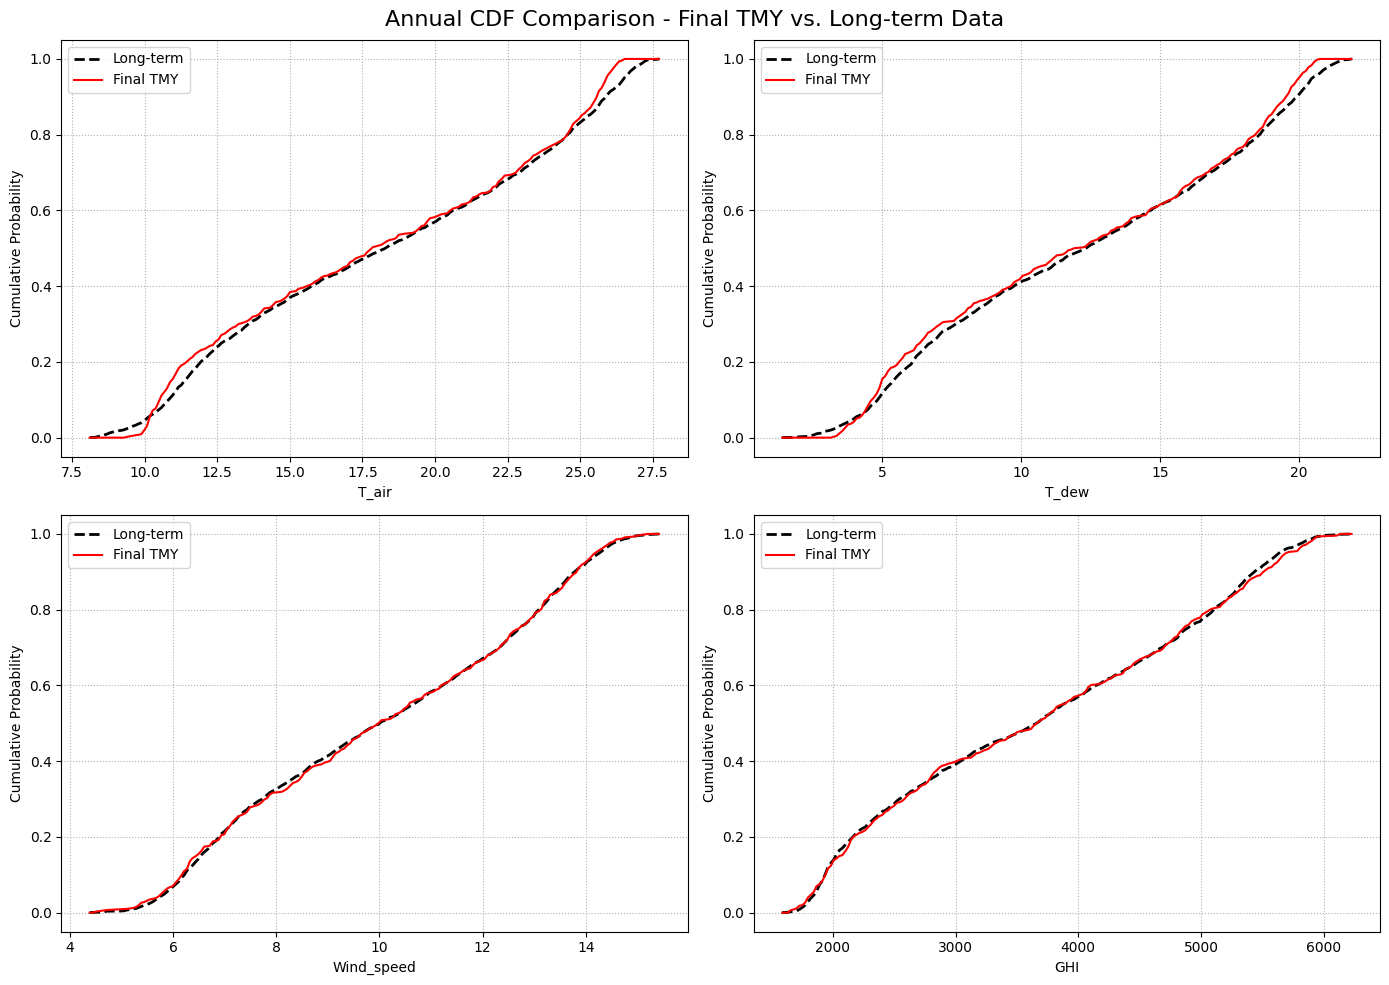

In [7]:
gen.plot_annual_cdfs()
plt.show()


Export the generated TMY to CSV (also supports `.xlsx`/`.tmy`). `export_tmy()` restores the original source column names, which is what makes the next step (`HourlyEPWConverter`) work without any extra `column_mapping`.

In [8]:
tmy_csv_path = os.path.join(OUT_DIR, "synthetic_tmy.csv")
gen.export_tmy(tmy_csv_path)


Exporting TMY to 'D:\Python\pyweatherfiles\examples\tutorial_output\synthetic_tmy.csv'...
Export completed successfully.


## 3. Convert the TMY to a final EPW with `HourlyEPWConverter`

We use one of the real Seville EPW files already bundled in
`longterm_epw/` as the geographic/time-zone **template** (`base_epw_path`):
latitude, longitude, elevation and time zone are extracted from it
automatically via Ladybug.


In [9]:
from pyweatherfiles import hourly_epw_converter

template_epw = os.path.join(REPO_ROOT, "longterm_epw", "seville_2005.epw")

tmy_converter = hourly_epw_converter.HourlyEPWConverter(
    file_path=tmy_csv_path,
    base_epw_path=template_epw,
)
print("Years found in the TMY csv (always [2000], the synthetic TMY year):", tmy_converter.available_years)

tmy_converter.process(
    output_dir=OUT_DIR,
    output_pattern="tutorial_seville_tmy.epw",
    save_session=False,
)

generated_tmy_epw = os.path.join(OUT_DIR, "tutorial_seville_tmy.epw")
assert os.path.exists(generated_tmy_epw)
print("Generated TMY EPW:", generated_tmy_epw)


Years found in the TMY csv (always [2000], the synthetic TMY year): [2000]

--- Procesando año 2000 de forma directa ---


¡Éxito! Año 2000 guardado en: D:\Python\pyweatherfiles\examples\tutorial_output\tutorial_seville_tmy.epw
Generated TMY EPW: D:\Python\pyweatherfiles\examples\tutorial_output\tutorial_seville_tmy.epw


## 4. Heating/cooling degree-hours with `DegreeHoursCalculator`

Setpoints are extracted directly from a real EnergyPlus IDF model bundled in
this repository (`SF_Detached_D_min_South.idf`), including its HVAC
availability schedules (hours where the system is off are masked out).


In [10]:
from pyweatherfiles.degree_hours import DegreeHoursCalculator

idf_path = os.path.join(REPO_ROOT, "SF_Detached_D_min_South.idf")
calc = DegreeHoursCalculator(generated_tmy_epw)


Quick visual QA of the setpoints (and HVAC availability gaps) before computing anything, for one January day:

[INFO] Cargando IDF: D:\Python\pyweatherfiles\SF_Detached_D_min_South.idf


[INFO] 'LivingRoom' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'Hall' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'OFFICE' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'Kitchen' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'DinnerRoom' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'BR1' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'


[INFO] 'BR2' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'BR3' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'BR4' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'BR5' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'WC' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[SUCCESS] Consignas extraídas para 11 zona(s).


[INFO] 'LivingRoom' -> heating availability: 'Heating Availability Schedule'
[INFO] 'LivingRoom' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'Hall' -> heating availability: 'Heating Availability Schedule'
[INFO] 'Hall' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'OFFICE' -> heating availability: 'Heating Availability Schedule'


[INFO] 'OFFICE' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'Kitchen' -> heating availability: 'Heating Availability Schedule'
[INFO] 'Kitchen' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'DinnerRoom' -> heating availability: 'Heating Availability Schedule'
[INFO] 'DinnerRoom' -> cooling availability: 'Cooling Availability Schedule'


[INFO] 'BR1' -> heating availability: 'Heating Availability Schedule'
[INFO] 'BR1' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'BR2' -> heating availability: 'Heating Availability Schedule'
[INFO] 'BR2' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'BR3' -> heating availability: 'Heating Availability Schedule'


[INFO] 'BR3' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'BR4' -> heating availability: 'Heating Availability Schedule'
[INFO] 'BR4' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'BR5' -> heating availability: 'Heating Availability Schedule'
[INFO] 'BR5' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'WC' -> heating availability: 'Heating Availability Schedule'
[INFO] 'WC' -> cooling availability: 'Cooling Availability Schedule'


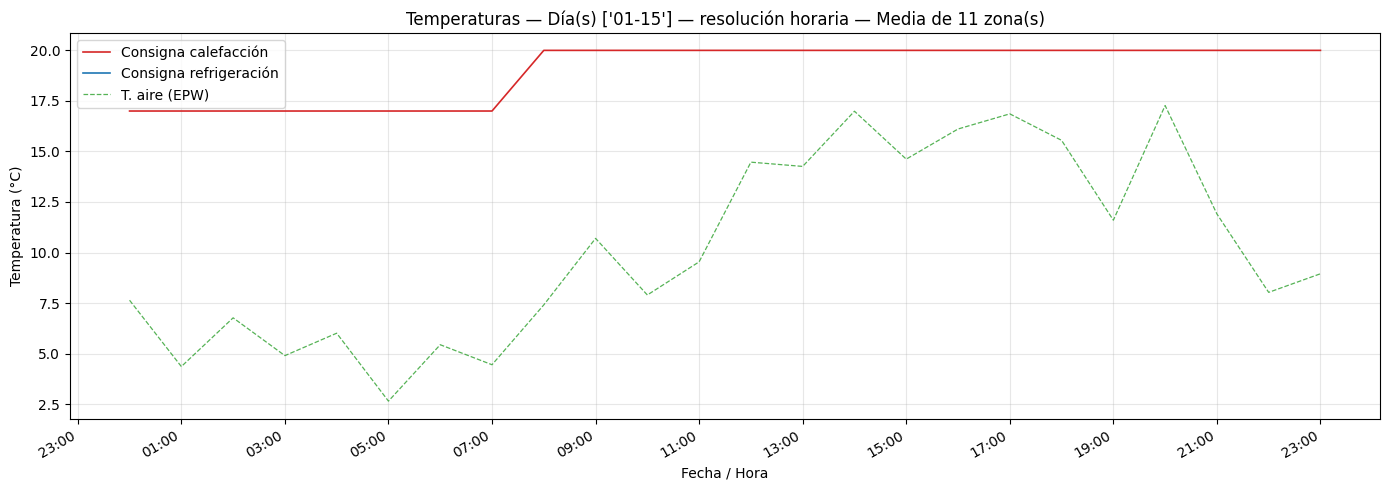

In [11]:
calc.plot(idf_path, period="day", period_value=["01-15"], show_air_temp=True)
plt.show()


In [12]:
results = calc.calculate(idf_path, frequency=["monthly"], mode="both", save_session=False)
results["monthly"]


[INFO] Cargando IDF: D:\Python\pyweatherfiles\SF_Detached_D_min_South.idf


[INFO] 'LivingRoom' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'Hall' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'OFFICE' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'Kitchen' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'DinnerRoom' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'BR1' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'


[INFO] 'BR2' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'BR3' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'BR4' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'BR5' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'WC' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[SUCCESS] Consignas extraídas para 11 zona(s).


[INFO] 'LivingRoom' -> heating availability: 'Heating Availability Schedule'
[INFO] 'LivingRoom' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'Hall' -> heating availability: 'Heating Availability Schedule'
[INFO] 'Hall' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'OFFICE' -> heating availability: 'Heating Availability Schedule'
[INFO] 'OFFICE' -> cooling availability: 'Cooling Availability Schedule'


[INFO] 'Kitchen' -> heating availability: 'Heating Availability Schedule'
[INFO] 'Kitchen' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'DinnerRoom' -> heating availability: 'Heating Availability Schedule'
[INFO] 'DinnerRoom' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'BR1' -> heating availability: 'Heating Availability Schedule'
[INFO] 'BR1' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'BR2' -> heating availability: 'Heating Availability Schedule'
[INFO] 'BR2' -> cooling availability: 'Cooling Availability Schedule'


[INFO] 'BR3' -> heating availability: 'Heating Availability Schedule'
[INFO] 'BR3' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'BR4' -> heating availability: 'Heating Availability Schedule'
[INFO] 'BR4' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'BR5' -> heating availability: 'Heating Availability Schedule'
[INFO] 'BR5' -> cooling availability: 'Cooling Availability Schedule'


[INFO] 'WC' -> heating availability: 'Heating Availability Schedule'
[INFO] 'WC' -> cooling availability: 'Cooling Availability Schedule'
[INFO] Consigna promediada sobre 11 zona(s).
[INFO] Calculando grados-hora (mode='both', horas=todas)…
[INFO] Cálculo completado.
  monthly: (12, 2) -> {'heating_dh': 28398.84, 'cooling_dh': 3220.04}


,heating_dh,cooling_dh
2000-01-31,6515.72,0.00
2000-02-29,5487.82,0.00
2000-03-31,3684.22,0.00
2000-04-30,1419.46,0.00
2000-05-31,0.00,338.90
2000-06-30,0.00,831.45
2000-07-31,0.00,1054.64
2000-08-31,0.00,729.10
2000-09-30,0.00,265.95
2000-10-31,1721.50,0.00


In [13]:
calc.export_results(os.path.join(OUT_DIR, "tutorial_degree_hours.xlsx"))


[INFO] Resultados exportados a: D:\Python\pyweatherfiles\examples\tutorial_output\tutorial_degree_hours.xlsx


'D:\\Python\\pyweatherfiles\\examples\\tutorial_output\\tutorial_degree_hours.xlsx'

## 5. Multi-EPW comparison with `EpwBatchAnalyzer`

We compare the freshly generated TMY against a real historical year
(`longterm_epw/seville_2019.epw`), with two hour-of-day scenarios
(`morning` vs `all_day`), still using the same IDF for setpoints.

```{warning}
`EpwBatchAnalyzer.run()` internally calls `DegreeHoursCalculator.calculate()`
once per EPW file, and does **not** expose a way to propagate
`save_session=False` to those internal calls (this is a current limitation of
the public API, not a bug we should silently patch here). As a result it
*will* write a `.pkl`/`.json` session pair next to every EPW it processes —
including inside the real `longterm_epw/` folder. We clean those up
explicitly right after `run()` so this tutorial does not leave stray files in
a tracked data folder.
```


In [14]:
from pyweatherfiles.degree_hours import EpwBatchAnalyzer

real_year_epw = os.path.join(REPO_ROOT, "longterm_epw", "seville_2019.epw")

batch = EpwBatchAnalyzer(
    epw_paths=[generated_tmy_epw, real_year_epw],
    setpoint_source=idf_path,
    epw_variables={"global_horizontal_radiation": ["sum", "mean"]},
    hours={"morning": list(range(9)), "all_day": list(range(24))},
    mode="both",
    frequencies=["monthly"],
)
batch_results = batch.run(save_session=False)
batch_results["monthly"].head()



[BATCH] tutorial_seville_tmy


[INFO] Cargando IDF: D:\Python\pyweatherfiles\SF_Detached_D_min_South.idf


[INFO] 'LivingRoom' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'Hall' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'OFFICE' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'Kitchen' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'DinnerRoom' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'BR1' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'BR2' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'


[INFO] 'BR3' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'BR4' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'BR5' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[INFO] 'WC' -> heating: 'Heating Set-point Schedule',  cooling: 'Cooling Set-point Schedule'
[SUCCESS] Consignas extraídas para 11 zona(s).
[INFO] 'LivingRoom' -> heating availability: 'Heating Availability Schedule'
[INFO] 'LivingRoom' -> cooling availability: 'Cooling Availability Schedule'


[INFO] 'Hall' -> heating availability: 'Heating Availability Schedule'
[INFO] 'Hall' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'OFFICE' -> heating availability: 'Heating Availability Schedule'
[INFO] 'OFFICE' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'Kitchen' -> heating availability: 'Heating Availability Schedule'


...

[INFO] 'LivingRoom' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'Hall' -> heating availability: 'Heating Availability Schedule'
[INFO] 'Hall' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'OFFICE' -> heating availability: 'Heating Availability Schedule'
[INFO] 'OFFICE' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'Kitchen' -> heating availability: 'Heating Availability Schedule'
[INFO] 'Kitchen' -> cooling availability: 'Cooling Availability Schedule'


[INFO] 'DinnerRoom' -> heating availability: 'Heating Availability Schedule'
[INFO] 'DinnerRoom' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'BR1' -> heating availability: 'Heating Availability Schedule'
[INFO] 'BR1' -> cooling availability: 'Cooling Availability Schedule'


[INFO] 'BR2' -> heating availability: 'Heating Availability Schedule'
[INFO] 'BR2' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'BR3' -> heating availability: 'Heating Availability Schedule'
[INFO] 'BR3' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'BR4' -> heating availability: 'Heating Availability Schedule'
[INFO] 'BR4' -> cooling availability: 'Cooling Availability Schedule'
[INFO] 'BR5' -> heating availability: 'Heating Availability Schedule'
[INFO] 'BR5' -> cooling availability: 'Cooling Availability Schedule'


[INFO] 'WC' -> heating availability: 'Heating Availability Schedule'
[INFO] 'WC' -> cooling availability: 'Cooling Availability Schedule'
[INFO] Consigna promediada sobre 11 zona(s).
[INFO] Calculando grados-hora (mode='both', horas=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23])…
[INFO] Cálculo completado.
  monthly: (12, 2) -> {'heating_dh': 25679.100000000002, 'cooling_dh': 5238.3}
[SESSION] Pickle guardado en: D:\Python\pyweatherfiles\longterm_epw\DegreeHoursCalculator_seville_2019_SF_Detached_D_min_South_both_3f407c53.pkl
[SESSION] JSON guardado en:   D:\Python\pyweatherfiles\longterm_epw\DegreeHoursCalculator_seville_2019_SF_Detached_D_min_South_both_3f407c53.json

[BATCH] Análisis completado.


epw      tutorial_seville_tmy                     \
variable   heating_dh_morning cooling_dh_morning   
month                                              
1                     3283.13                0.0   
2                     2844.90                0.0   
3                     2197.80                0.0   
4                     1041.74                0.0   
5                        0.00                0.0   

epw                                               \
variable global_horizontal_radiation_sum_morning   
month                                              
1                                           5591   
2                                           6568   
3                                           9460   
4                                          11887   
5                                          13740   

epw                                                                   \
variable global_horizontal_radiation_mean_morning heating_dh_all_day   
month                                                                  
1                                       20.039427            6515.72   
2                                       25.164751            5487.82   
3                                       33.906810            3684.22   
4                                       44.025926            1419.46   
5                                       49.247312               0.00   

epw                                                                  \
variable cooling_dh_all_day global_horizontal_radiation_sum_all_day   
month                                                                 
1                       0.0                                   63805   
2                       0.0                                   76457   
3                       0.0                                  107740   
4                       0.0                                  132495   
5                     338.9                                  160655   

epw                                                     seville_2019  \
variable global_horizontal_radiation_mean_all_day heating_dh_morning   
month                                                                  
1                                       85.759409             3113.8   
2                                      109.852011             2419.2   
3                                      144.811828             1772.3   
4                                      184.020833             1452.5   
5                                      215.934140                0.0   

epw                                                                  \
variable cooling_dh_morning global_horizontal_radiation_sum_morning   
month                                                                 
1                       0.0                                    3570   
2                       0.0                                    6283   
3                       0.0                                   13941   
4                       0.0                                   22211   
5                       0.0                                   33890   

epw                                                                   \
variable global_horizontal_radiation_mean_morning heating_dh_all_day   
month                                                                  
1                                       12.795699             6868.5   
2                                       24.072797             4664.2   
3                                       49.967742             3011.4   
4                                       82.262963             2631.1   
5                                      121.469534                0.0   

epw                                                                  \
variable cooling_dh_all_day global_horizontal_radiation_sum_all_day   
month                                                                 
1                       0.0                                   93826   
2            

In [15]:
batch.export(os.path.join(OUT_DIR, "tutorial_batch_degree_hours.xlsx"))


[INFO] Results exported to: D:\Python\pyweatherfiles\examples\tutorial_output\tutorial_batch_degree_hours.xlsx


'D:\\Python\\pyweatherfiles\\examples\\tutorial_output\\tutorial_batch_degree_hours.xlsx'

In [16]:
# Cleanup: remove the session files EpwBatchAnalyzer wrote into the real,
# version-controlled longterm_epw/ folder (see warning above).
import glob

removed = []
for pattern in ("DegreeHoursCalculator_seville_2019_*.pkl", "DegreeHoursCalculator_seville_2019_*.json"):
    for f in glob.glob(os.path.join(REPO_ROOT, "longterm_epw", pattern)):
        os.remove(f)
        removed.append(f)
print(f"Removed {len(removed)} stray session file(s) from longterm_epw/.")


Removed 2 stray session file(s) from longterm_epw/.


## 6. Bonus: multi-year warming trend with `EpwTrendAnalyzer`

`longterm_epw/` already contains one real annual EPW per year for Seville,
**2005-2025, with 2020 deliberately missing** — a good opportunity to see how
`discover_files()`/`coverage_df` reports data-coverage gaps.

```{note}
`TrendConfig.root_dir` / `OutputConfig.output_dir` are typed as
`pathlib.Path`, not `str` — pass `Path(...)` objects as shown below.
```


In [17]:
from pathlib import Path
from pyweatherfiles import EpwTrendAnalyzer, TrendConfig, OutputConfig

trend_out_dir = Path(OUT_DIR) / "trend_results"
analyzer = EpwTrendAnalyzer(
    trend_config=TrendConfig(root_dir=Path(REPO_ROOT) / "longterm_epw"),
    output_config=OutputConfig(output_dir=trend_out_dir),
)
analyzer.run()
analyzer.coverage_df


,city,n_years,min_year,max_year,missing_years
0,seville,20,2005,2025,2020


Per-city OLS trend (mean and P95 annual temperature vs. year):

In [18]:
analyzer.city_trends_df

,city,target,slope_c_per_year,intercept,r2,p_value,std_error,n_years
0,seville,t_mean_annual,0.024642,-30.434819,0.094730,0.186790,0.017955,20
1,seville,t_p95_annual,0.076140,-119.661595,0.215491,0.039219,0.034242,20


Global fixed-effects model (`target ~ year + C(city)`) for the primary target, `t_mean_annual`:

In [19]:
analyzer.global_results["t_mean_annual"]

FixedEffectResult(target='t_mean_annual', slope_c_per_year=0.02464176462869143, intercept=-30.434818855334058, std_error=0.017954819163799332, t_stat=1.3724317913696606, p_value=0.18679003557627105, ci95_low=-0.013079910681076758, ci95_high=0.062363439938459615, r2=0.09472992599363939, n_obs=20, n_cities=1, df_resid=18)

## Wrap-up & next steps

This notebook covered the full pipeline: synthetic hourly data ->
`TMYGenerator` -> `HourlyEPWConverter` -> `DegreeHoursCalculator` ->
`EpwBatchAnalyzer` -> `EpwTrendAnalyzer`. All generated files live under
`examples/tutorial_output/` (safe to delete and regenerate at any time; it is
excluded from git via `.gitignore`).

Where to go next:

- Full technical reference (every module, class, formula): [`README.md`](../README.md) / [`README_ES.md`](../README_ES.md).
- Real Seville production script (uses the actual station data + the official `.met` reference file): [`generating epws seville.py`](../generating%20epws%20seville.py) and [`ARTICLE_CONTEXT_SEVILLA.md`](../ARTICLE_CONTEXT_SEVILLA.md).
- Simpler, focused examples: [`examples/using_tmy_generator.py`](using_tmy_generator.py), [`examples/degreehours simple.py`](degreehours%20simple.py), [`examples/degreehours batch.py`](degreehours%20batch.py).
- Auto-generated API reference: build the Sphinx docs in `docs/` (see `docs/source/installation.md`).
